## 1. Student Performance 

In [1]:
import numpy as np
import pandas as pd


In [2]:
np.random.seed(42)

In [5]:
df = pd.DataFrame({
    "student_id": range(1, 501),
    "study_hours": np.random.randint(1, 10, 500),
    "attendance": np.random.randint(50, 100, 500),
    "exam_score": np.random.randint(30, 100, 500)
})

#### Basic inspection
----

In [6]:
df.head()

,student_id,study_hours,attendance,exam_score
0,1,7,80,37
1,2,4,68,34
2,3,8,93,58
3,4,5,88,76
4,5,7,76,97


In [7]:
df.tail()

,student_id,study_hours,attendance,exam_score
495,496,7,85,85
496,497,9,94,50
497,498,4,73,76
498,499,4,64,88
499,500,6,78,35


In [8]:
df.sample(5)

,student_id,study_hours,attendance,exam_score
56,57,2,81,70
418,419,7,61,71
494,495,1,96,96
217,218,3,52,83
290,291,9,66,44


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   student_id   500 non-null    int64
 1   study_hours  500 non-null    int64
 2   attendance   500 non-null    int64
 3   exam_score   500 non-null    int64
dtypes: int64(4)
memory usage: 15.8 KB


#### Feature engineering
---

In [11]:
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"] 
)
df

,student_id,study_hours,attendance,exam_score,performance
0,1,7,80,37,Low
1,2,4,68,34,Low
2,3,8,93,58,Medium
3,4,5,88,76,High
4,5,7,76,97,High
...,...,...,...,...,...
495,496,7,85,85,High
496,497,9,94,50,Low
497,498,4,73,76,High
498,499,4,64,88,High


#### Statistical analysis
---

In [12]:
df.describe()

,student_id,study_hours,attendance,exam_score
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,4.906000,73.926000,64.308000
std,144.481833,2.612051,14.456227,19.808733
min,1.000000,1.000000,50.000000,30.000000
25%,125.750000,3.000000,61.000000,47.000000
50%,250.500000,5.000000,75.000000,65.000000
75%,375.250000,7.000000,86.000000,82.000000
max,500.000000,9.000000,99.000000,99.000000


In [13]:
df[['study_hours','attendance','exam_score']].mean()

study_hours     4.906
attendance     73.926
exam_score     64.308
dtype: float64

#### Group analysis
----

In [15]:
df.groupby("performance")["exam_score"].agg(["mean","min","max","count"])

,mean,min,max,count
performance,,,,
Low,39.958904,30,50,146
Medium,62.881720,51,75,186
High,87.047619,76,99,168


#### Filtering
---

In [16]:
high_performers = df[(df["study_hours"] > 6) & (df["attendance"] > 80)]
high_performers

,student_id,study_hours,attendance,exam_score,performance
2,3,8,93,58,Medium
10,11,8,94,55,Medium
25,26,7,82,72,Medium
31,32,7,94,80,High
37,38,9,86,30,Low
...,...,...,...,...,...
481,482,7,86,75,Medium
483,484,9,82,33,Low
490,491,8,82,31,Low
495,496,7,85,85,High


#### Sorting
---

In [17]:
df.sort_values("exam_score", ascending=False).head(10)

,student_id,study_hours,attendance,exam_score,performance
255,256,3,85,99,High
72,73,9,90,99,High
393,394,7,51,99,High
179,180,2,76,99,High
447,448,1,89,99,High
340,341,3,80,99,High
152,153,3,52,98,High
398,399,2,50,98,High
221,222,8,78,98,High
13,14,6,77,98,High


#### Correlation
___

In [19]:
df.corr(numeric_only=True)

,student_id,study_hours,attendance,exam_score
student_id,1.000000,-0.047810,-0.017097,0.028112
study_hours,-0.047810,1.000000,0.046094,-0.005830
attendance,-0.017097,0.046094,1.000000,-0.042155
exam_score,0.028112,-0.005830,-0.042155,1.000000


### *Visualization (Matplotlib + Seaborn)*
----

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Pairplot
---

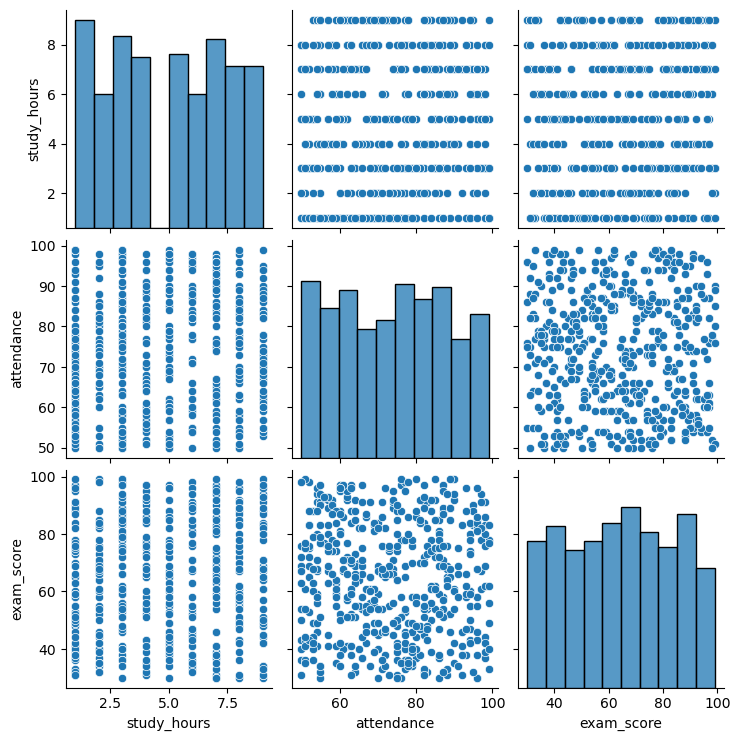

In [25]:
sns.pairplot(df[["study_hours", "attendance", "exam_score"]])
plt.show()

#### Heatmap
---

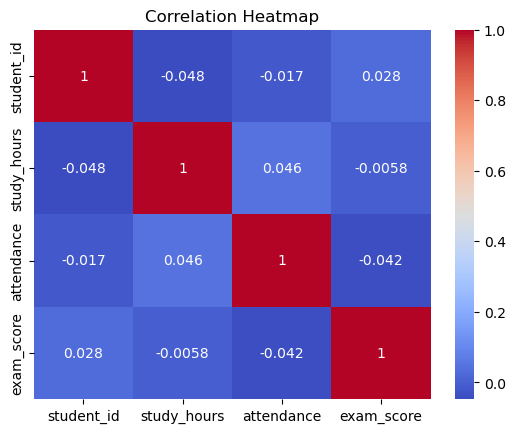

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Boxplot
----

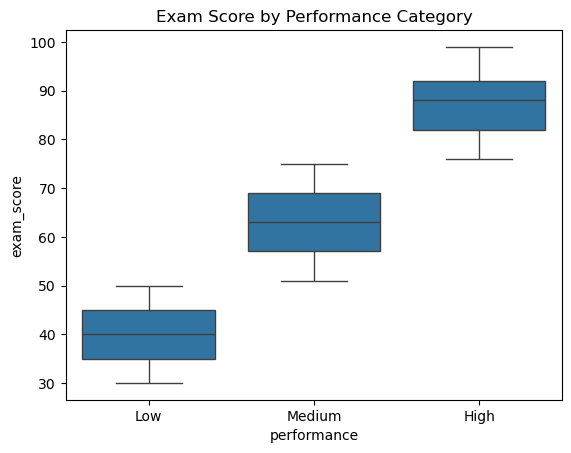

In [28]:
sns.boxplot(x="performance", y="exam_score", data=df)
plt.title("Exam Score by Performance Category")
plt.show()

#### Line plot (sorted)
---

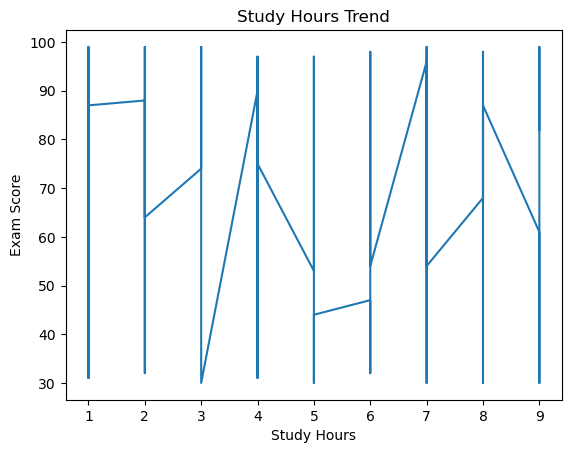

In [29]:
df_sorted = df.sort_values("study_hours")
plt.plot(df_sorted["study_hours"], df_sorted["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours Trend")
plt.show()

-----
-----
## 2. Employee Analytics

#### Dataset Creation
---

In [31]:
np.random.seed(10)

In [35]:
df = pd.DataFrame({
    "employee_id": range(1, 501),
    "experience_years": np.random.randint(0, 20, 500),
    "salary": np.random.randint(20000, 150000, 500),
    "performance_rating": np.random.randint(1, 6, 500),
    "department": np.random.choice(["IT", "HR", "Sales", "Finance"], 500)
})

#### Inspection
---

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   employee_id         500 non-null    int64
 1   experience_years    500 non-null    int64
 2   salary              500 non-null    int64
 3   performance_rating  500 non-null    int64
 4   department          500 non-null    str  
dtypes: int64(4), str(1)
memory usage: 19.7 KB


In [39]:
df.describe(include="all")

,employee_id,experience_years,salary,performance_rating,department
count,500.000000,500.000000,500.000000,500.00000,500
unique,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,Finance
freq,NaN,NaN,NaN,NaN,134
mean,250.500000,9.576000,85823.474000,3.14200,NaN
std,144.481833,5.811348,37365.391537,1.43176,NaN
min,1.000000,0.000000,20439.000000,1.00000,NaN
25%,125.750000,4.000000,53830.750000,2.00000,NaN
50%,250.500000,10.000000,82455.500000,3.00000,NaN
75%,375.250000,14.000000,118756.250000,4.00000,NaN


#### GroupBy with multiple columns
---

In [40]:
df.groupby("department")["salary"].agg(["mean", "median", "max"])

,mean,median,max
department,,,
Finance,81503.716418,75362.0,148364
HR,90679.735537,92929.0,149683
IT,85321.067797,81965.0,149586
Sales,86221.299213,80565.0,149980


#### Pivot table
----

In [42]:
pd.pivot_table(
    df,
    values="salary",
    index="department",
    columns="performance_rating",
    aggfunc="mean"
)
# Pivot table that shows the average salary for each department, split by performance rating

performance_rating,1,2,3,4,5
department,,,,,
Finance,81104.160000,85037.458333,82488.243243,70636.880000,88478.608696
HR,100359.392857,91616.900000,87315.411765,87145.333333,86062.406250
IT,87228.222222,87855.304348,91206.454545,78431.142857,83044.411765
Sales,97974.250000,89322.533333,88520.095238,78749.807692,82247.764706


#### Ranking
---

In [44]:
df["salary_rank"] = df["salary"].rank(ascending=False)
df

,employee_id,experience_years,salary,performance_rating,department,salary_rank
0,1,9,122555,2,Sales,111.0
1,2,12,118327,4,Finance,127.0
2,3,2,50855,3,Finance,389.0
3,4,1,89117,2,IT,235.0
4,5,2,113951,4,Finance,149.0
...,...,...,...,...,...,...
495,496,17,77582,4,Sales,278.0
496,497,13,76960,1,HR,279.0
497,498,2,104122,3,HR,184.0
498,499,19,43251,1,IT,421.0


In [45]:
df["level"] = np.where(df["experience_years"] >= 10, "Senior", "Junior")
df

,employee_id,experience_years,salary,performance_rating,department,salary_rank,level
0,1,9,122555,2,Sales,111.0,Junior
1,2,12,118327,4,Finance,127.0,Senior
2,3,2,50855,3,Finance,389.0,Junior
3,4,1,89117,2,IT,235.0,Junior
4,5,2,113951,4,Finance,149.0,Junior
...,...,...,...,...,...,...,...
495,496,17,77582,4,Sales,278.0,Senior
496,497,13,76960,1,HR,279.0,Senior
497,498,2,104122,3,HR,184.0,Junior
498,499,19,43251,1,IT,421.0,Senior


#### Value counts
---

In [48]:
df["department"].value_counts(normalize=True)

department
Finance    0.268
Sales      0.254
HR         0.242
IT         0.236
Name: proportion, dtype: float64

### *Visualization*
----

#### Salary distribution

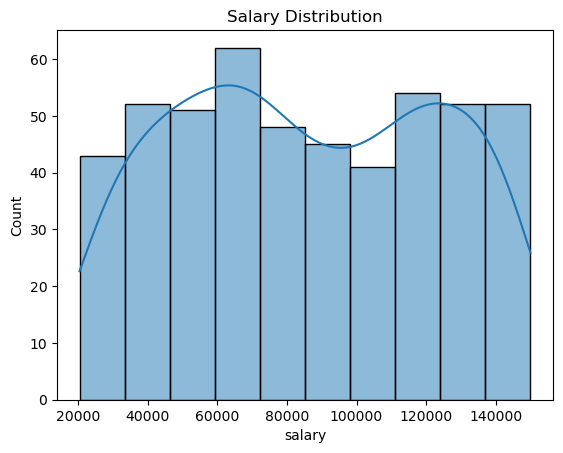

In [49]:
sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

#### Experience vs Salary

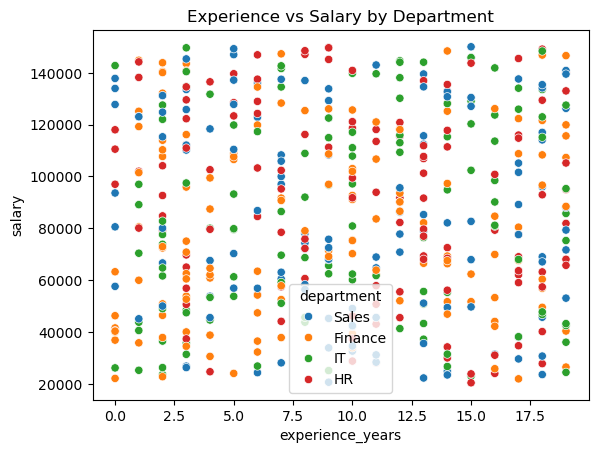

In [50]:
sns.scatterplot(x="experience_years", y="salary", hue="department", data=df)
plt.title("Experience vs Salary by Department")
plt.show()

#### Bar plot

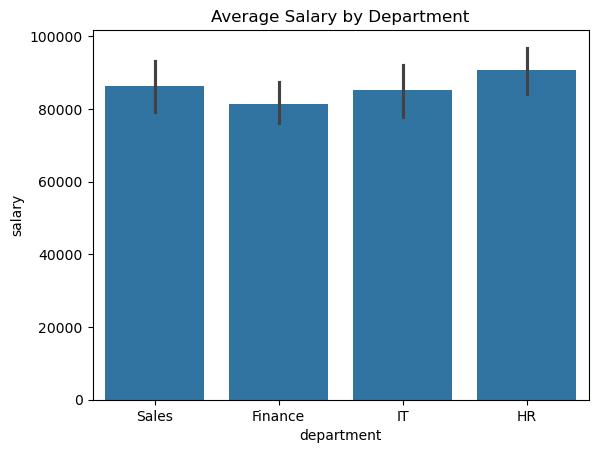

In [51]:
sns.barplot(x="department", y="salary", data=df)
plt.title("Average Salary by Department")
plt.show()

#### Boxplot

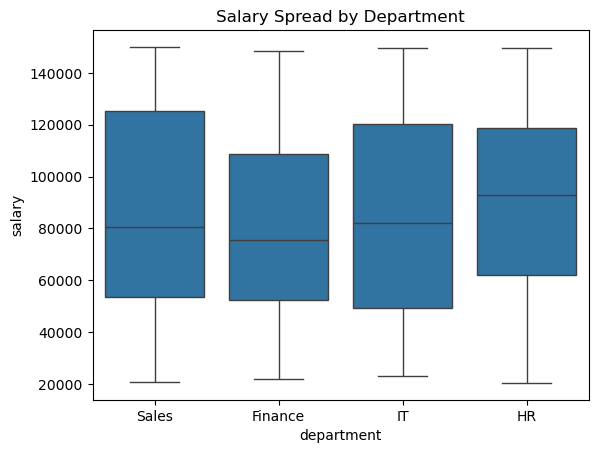

In [52]:
sns.boxplot(x="department", y="salary", data=df)
plt.title("Salary Spread by Department")
plt.show()